# IMPORTS

In [1]:
from qiskit import *
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_state_city
import qiskit.quantum_info as qi
from qiskit.visualization import plot_histogram
from math import gcd
from numpy.random import randint
import pandas as pd
from fractions import Fraction
from tqdm import tqdm
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
import matplotlib.pyplot as plt
import random
import sys
import math
import array
import fractions
import numpy as np
import matplotlib.pyplot as plt



# IMPLEMENTATION , 

## QFT and QFT$^{-1}$
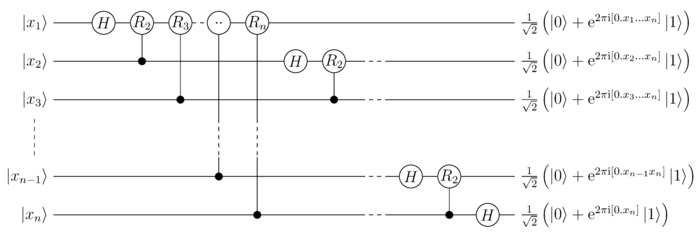

In [2]:
''' Function to create QFT for a given circuit and its up_reg (num = n) , also has a 
swap-condition to increase functionality ,
doing the swaps (optional because in places like mod multiplication the goal
isnt to get QFT but to rather add/multiply for which swap is unnecessary so it jus
contributes to inreasing gate count ''' 
def create_QFT(circuit , up_reg , n , with_swap):
    i = n-1
    # pre swap , we do the operations
    while i >= 0:
        circuit.h(up_reg[i])
        j = i-1
        # now we apply the controlled phase gates R_k
        while j>=0:
            # applying phase gate to up_reg[j], controlled by up_reg[i]
            if (np.pi)/(pow(2,(i-j))) > 0 :
                circuit.cp((np.pi)/(pow(2,(i-j))) , up_reg[i] , up_reg[j])
            j-=1
        i-=1
    # this is the end of the qft thing usually (with_swap = 0 usually)
    if with_swap == 1:
            i = 0
            while i < (n-1)/2:
                circuit.swap(up_reg[i] , up_reg[n-i-1])
                i+=1

def create_inverse_QFT(circuit,up_reg,n,with_swaps):
    # If specified, apply the Swaps at the beggining
    if with_swaps==1:
        i=0
        while i < ((n-1)/2):
            circuit.swap(up_reg[i], up_reg[n-1-i])
            i=i+1
    
    # just reversing the operations in QFT
    i=0
    while i<n:
        circuit.h(up_reg[i])
        if i != n-1:
            j=i+1
            y=i
            while y>=0:
                 if (np.pi)/(pow(2,(j-y))) > 0:
                    circuit.cp( - (np.pi)/(pow(2,(j-y))) , up_reg[j] , up_reg[y] )
                    y=y-1   
        i=i+1

# MODULAR MULTIPLICATION

## Helper functions

In [3]:
def c_cphase(circuit , angle , ctl1 , ctl2 , tgt):
    # applies doubly controlled phase gate
    circuit.cp(angle/2 , ctl1 , tgt)
    circuit.cx(ctl2,ctl1)
    circuit.cp(-angle/2 , ctl1 , tgt)
    circuit.cx(ctl2,ctl1)
    circuit.cp(angle/2 , ctl2 , tgt)
"""Function that calculates the array of angles to be used in the addition in Fourier Space"""
def getAngles(a,N): # note : N here is just the no. of qubits for adding a , not the N = pq
    s=bin(int(a))[2:].zfill(N) 
    angles=np.zeros([N])
    for i in range(0, N):
        for j in range(i,N):
            if s[j]=='1':
                angles[N-i-1]+=math.pow(2, -(j-i))
        angles[N-i-1]*=np.pi
    return angles

''' ckt to perform add by a in the fourier space
equivalent to subtracter if inv is set to !0 
q is array of qubits in the ckt '''
def phi_add(circuit , q , a , n , inv ): # n here is number of qubits more or less
    angle = getAngles(a,n)
    for i in range(n):
        if inv == 0:
            circuit.p(angle[i],q[i])
        else:
            circuit.p(-angle[i],q[i])
            
"""Single controlled version of the phiADD circuit"""
def cphiADD(circuit,q,ctl,a,n,inv): # n here is number of qubits
    angle=getAngles(a,n)
    for i in range(0,n):
        if inv==0:
            circuit.cp(angle[i],ctl,q[i])
        else:
            circuit.cp(-angle[i],ctl,q[i])
            
    
# doubly controlled addition by a in the fourier space
def c_cphiadd(circuit,q,ctl1,ctl2,a,N,inv):
    angle = getAngles(a,N)
    for i in range(N):
        if inv == 0:
            c_cphase(circuit , angle[i] , ctl1,ctl2,q[i])
        else:
            c_cphase(circuit , -angle[i] , ctl1,ctl2,q[i])
            
def egcd(a, b):
    if a == 0:
        return (b, 0, 1)
    else:
        g, y, x = egcd(b % a, a)
        return (g, x - (b // a) * y, y)


def modinv(a, m):
    g, x, y = egcd(a, m)
    if g != 1:
        raise Exception('modular inverse does not exist')
    else:
        return x % m

def get_coprime(N):
    return random.randint(2,N-2)

## Modular addition + it's inverse : doubly controlled

In [4]:
# doing doubly modular addition by a (mod N)
def c_cphiadd_modN(circuit , q, ctl1, ctl2 , aux , a, N,n):
    c_cphiadd(circuit,q,ctl1,ctl2,a,n,0) # add a
    phi_add(circuit,q,N,n,1) # subtract N
    create_inverse_QFT(circuit,q,n,0) # inv Qft to check msb for doing modular addn
    circuit.cx(q[n-1],aux) # checking if addition by a exceeds N
    create_QFT(circuit , q , n , 0) # recreating qft after check
    cphiADD(circuit,q,aux,N,n,0) # adding N back if a's addition didnt exceed N


    c_cphiadd(circuit,q,ctl1,ctl2,a,n,1) # subtracting a
    create_inverse_QFT(circuit,q,n,0) 
    circuit.x(q[n-1])
    circuit.cx(q[n-1],aux)
    circuit.x(q[n-1])
    create_QFT(circuit , q , n , 0) # recreating qft after check
    c_cphiadd(circuit,q,ctl1,ctl2,a,n,0)

# ckt to implement inv of doubly controlled modular addition (reverse each gate and order)
def c_cphiadd_modN_inv(circuit, q, ctl1, ctl2, aux, a, N, n):
    c_cphiadd(circuit, q, ctl1, ctl2, a, n, 1)
    create_inverse_QFT(circuit, q, n, 0)
    circuit.x(q[n-1])
    circuit.cx(q[n-1],aux)
    circuit.x(q[n-1])
    create_QFT(circuit, q, n, 0)
    c_cphiadd(circuit, q, ctl1, ctl2, a, n, 0)
    cphiADD(circuit, q, aux, N, n, 1)
    create_inverse_QFT(circuit, q, n, 0)
    circuit.cx(q[n-1], aux)
    create_QFT(circuit, q, n, 0)
    phi_add(circuit, q, N, n, 0)
    c_cphiadd(circuit, q, ctl1, ctl2, a, n, 1)

## Modular multiplication

In [5]:
def c_mult_modN(circuit,ctl1,q,aux,a,N,n): # controlled mult. by a (mod N)
    # aux is an array of n+1 qubits set to |0>
    create_QFT(circuit,aux,n+1,0)
    for i in range(n):
        c_cphiadd_modN(circuit,aux,q[i],ctl1,aux[n+1],(2**i)*a%N,N,n+1)
    create_inverse_QFT(circuit, aux, n+1, 0)
    for i in range(0,n): # swap contents 
        circuit.cswap(ctl1,q[i],aux[i])
    a_inv = modinv(a,N)
    # now multilpying contents of 2nd reg ( now in state |q> ) with a-1 mod N * aqmodN essentially
    create_QFT(circuit,aux,n+1,0)
    for i in range(n-1,-1,-1):
        c_cphiadd_modN_inv(circuit,aux,q[i],ctl1,aux[n+1],math.pow(2,i)*a_inv%N,N,n+1)
    create_inverse_QFT(circuit, aux, n+1, 0)
    


## Final Circuit

In [6]:
def DLP_Quantum_Circuit(N, a, b, r):
    n = math.ceil(math.log(N, 2))
    down_reg = QuantumRegister(n, 'target') 
    up_reg = QuantumRegister(2 * n, 'control') 
    aux = QuantumRegister(n + 2, 'aux')
    stage1_results = ClassicalRegister(2 * n, 'stage1')
    stage2_results = ClassicalRegister(2 * n, 'stage2')
    
    circuit = QuantumCircuit(down_reg, up_reg, aux, stage1_results, stage2_results)
    circuit.x(down_reg[0])
    # STAGE 1: Phase Estimation of U_a
    circuit.h(up_reg)
    for i in range(2 * n):
        c_mult_modN(circuit, up_reg[i], down_reg, aux, int(pow(a, pow(2, i))), N, n)
    create_inverse_QFT(circuit, up_reg, 2 * n, 1)
    #Measure to |psi_k>
    circuit.measure(up_reg, stage1_results)
    circuit.barrier()
    # reset
    circuit.reset(up_reg)
    # STAGE 2: Phase Estimation of U_b
    circuit.h(up_reg)
    for i in range(2 * n):
        c_mult_modN(circuit, up_reg[i], down_reg, aux, int(pow(b, pow(2, i))), N, n)
    create_inverse_QFT(circuit, up_reg, 2 * n, 1)
    
    #Measure phase
    circuit.measure(up_reg, stage2_results)
    return circuit
def solve_for_m(y1_int, y2_int, r, n):
    phase1 = y1_int / (2**(2*n))
    phase2 = y2_int / (2**(2*n))
    k = round(phase1 * r)
    mk_mod_r = round(phase2 * r)
    print("k : ",k)
    try:
        k_inv = pow(k, -1, r)
        m = (mk_mod_r * k_inv) % r
        return m
    except ValueError:
        return "k and r not coprime, try again."


## Running circuit

In [7]:
N = 23
a = 2
b = 9
#Pre-calculate r (in practice this will be done via shor's algorithm circuit, but just to save time and focus on dlp , we solve it manually here)
r = None
for i in range(1, N):
    if pow(a, i, N) == 1:
        r = i
        break
n = math.ceil(math.log(N, 2))
qc = DLP_Quantum_Circuit(N, a, b, r)
print(" made circuit ")
backend = AerSimulator()

t_qc = transpile(qc, backend)
print(" transpiled ckt ")
job = backend.run(t_qc, shots=1, memory=True)
print( " ran ckt ")
raw_result = job.result().get_memory()[0]
print(f"Raw bits: {raw_result}")


 made circuit 
 transpiled ckt 
 ran ckt 
Raw bits: 1000101111 1110100011


In [8]:
res_split = raw_result.split()
y2_int = int(res_split[0], 2)
y1_int = int(res_split[1], 2)
print(f"Stage 1 (y1): {y1_int}")
print(f"Stage 2 (y2): {y2_int}")
m_result = solve_for_m(y1_int, y2_int, r, n)
if isinstance(m_result, int):
    check = pow(a, m_result, N)
    print(f"--- SUCCESS ---")
    print(f"Calculated Discrete Log m = {m_result}")
    print(f"Verification: {a}^{m_result} mod {N} = {check}")
    if check == b:
        print("MATCH! The logarithm is correct.")
    else:
        print("Mismatch. The phase estimation might have been inaccurate.")
else:
    print(f"--- FAILED ---")
    print(f"Reason: {m_result}")
print(r)

Stage 1 (y1): 931
Stage 2 (y2): 559
k :  10
--- SUCCESS ---
Calculated Discrete Log m = 5
Verification: 2^5 mod 23 = 9
MATCH! The logarithm is correct.
11


## Depth 
Note : primes above and equal to 79 exceed the circuit width value

In [ ]:
N = 79
a = 3
b = 10
#Pre-calculate r (in practice this will be done via shor's algorithm circuit, but just to save time and focus on dlp , we solve it manually here)
r = None
for i in range(1, N):
    if pow(a, i, N) == 1:
        r = i
        break
n = math.ceil(math.log(N, 2))
qc = DLP_Quantum_Circuit(N, a, b, r)
print(" made circuit ")
backend = AerSimulator()
t_qc = transpile(qc, backend)
print(" transpiled ckt ")
depth = t_qc.decompose().depth()
print("Depth:" ,depth )
list_N[(N,a,b)] = depth


{(7, 3, 13): 13723, (13, 6, 10): 33525, (19, 2, 17): 64279, (23, 2, 19): 62325, (31, 3, 26): 64820, (53, 2, 15): 112471, (61, 2, 3): 112357}


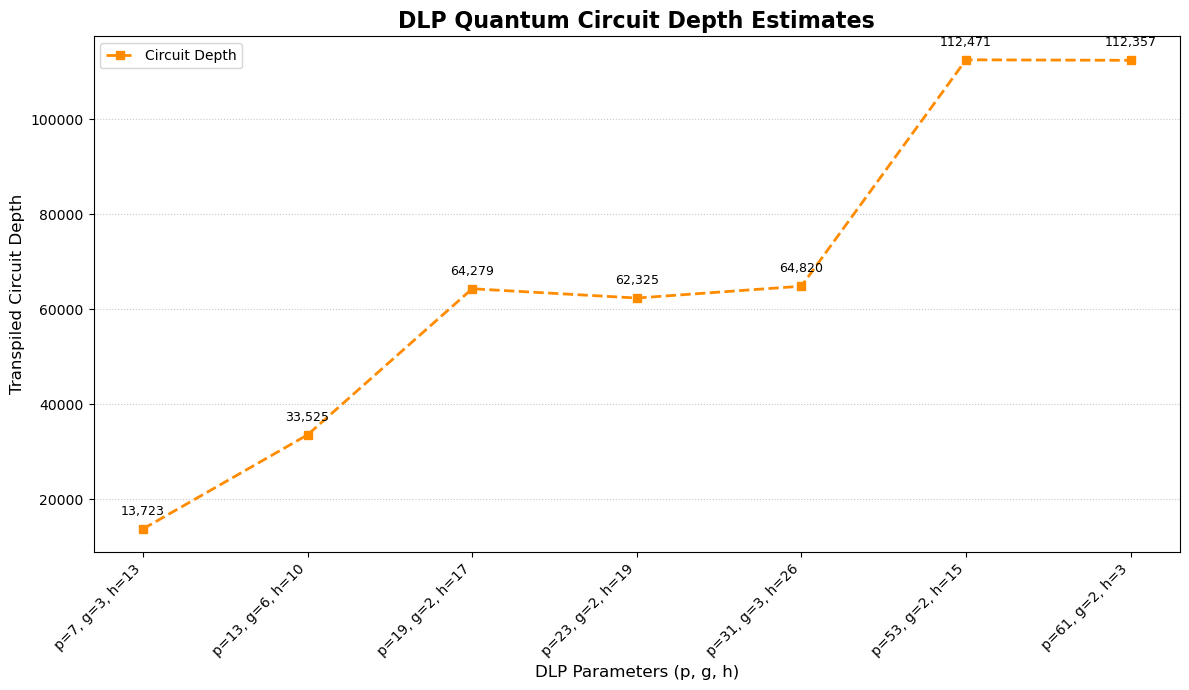

In [18]:
print(list_N)
sorted_cases = sorted(list_N.items(), key=lambda x: x[0][0])

labels = [f"p={k[0]}, g={k[1]}, h={k[2]}" for k, v in sorted_cases]
depths = [v for k, v in sorted_cases]
primes = [k[0] for k, v in sorted_cases]
plt.figure(figsize=(12, 7))
plt.plot(labels, depths, marker='s', linestyle='--', color='darkorange', linewidth=2, label='Circuit Depth')

for i, depth in enumerate(depths):
    plt.annotate(f'{depth:,}', (i, depths[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

# Formatting the chart
plt.title("DLP Quantum Circuit Depth Estimates", fontsize=16, fontweight='bold')
plt.xlabel("DLP Parameters (p, g, h)", fontsize=12)
plt.ylabel("Transpiled Circuit Depth", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.legend()

plt.show()